C:\Users\madhu\AppData\Local\Temp\ipykernel_30012\1620329377.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


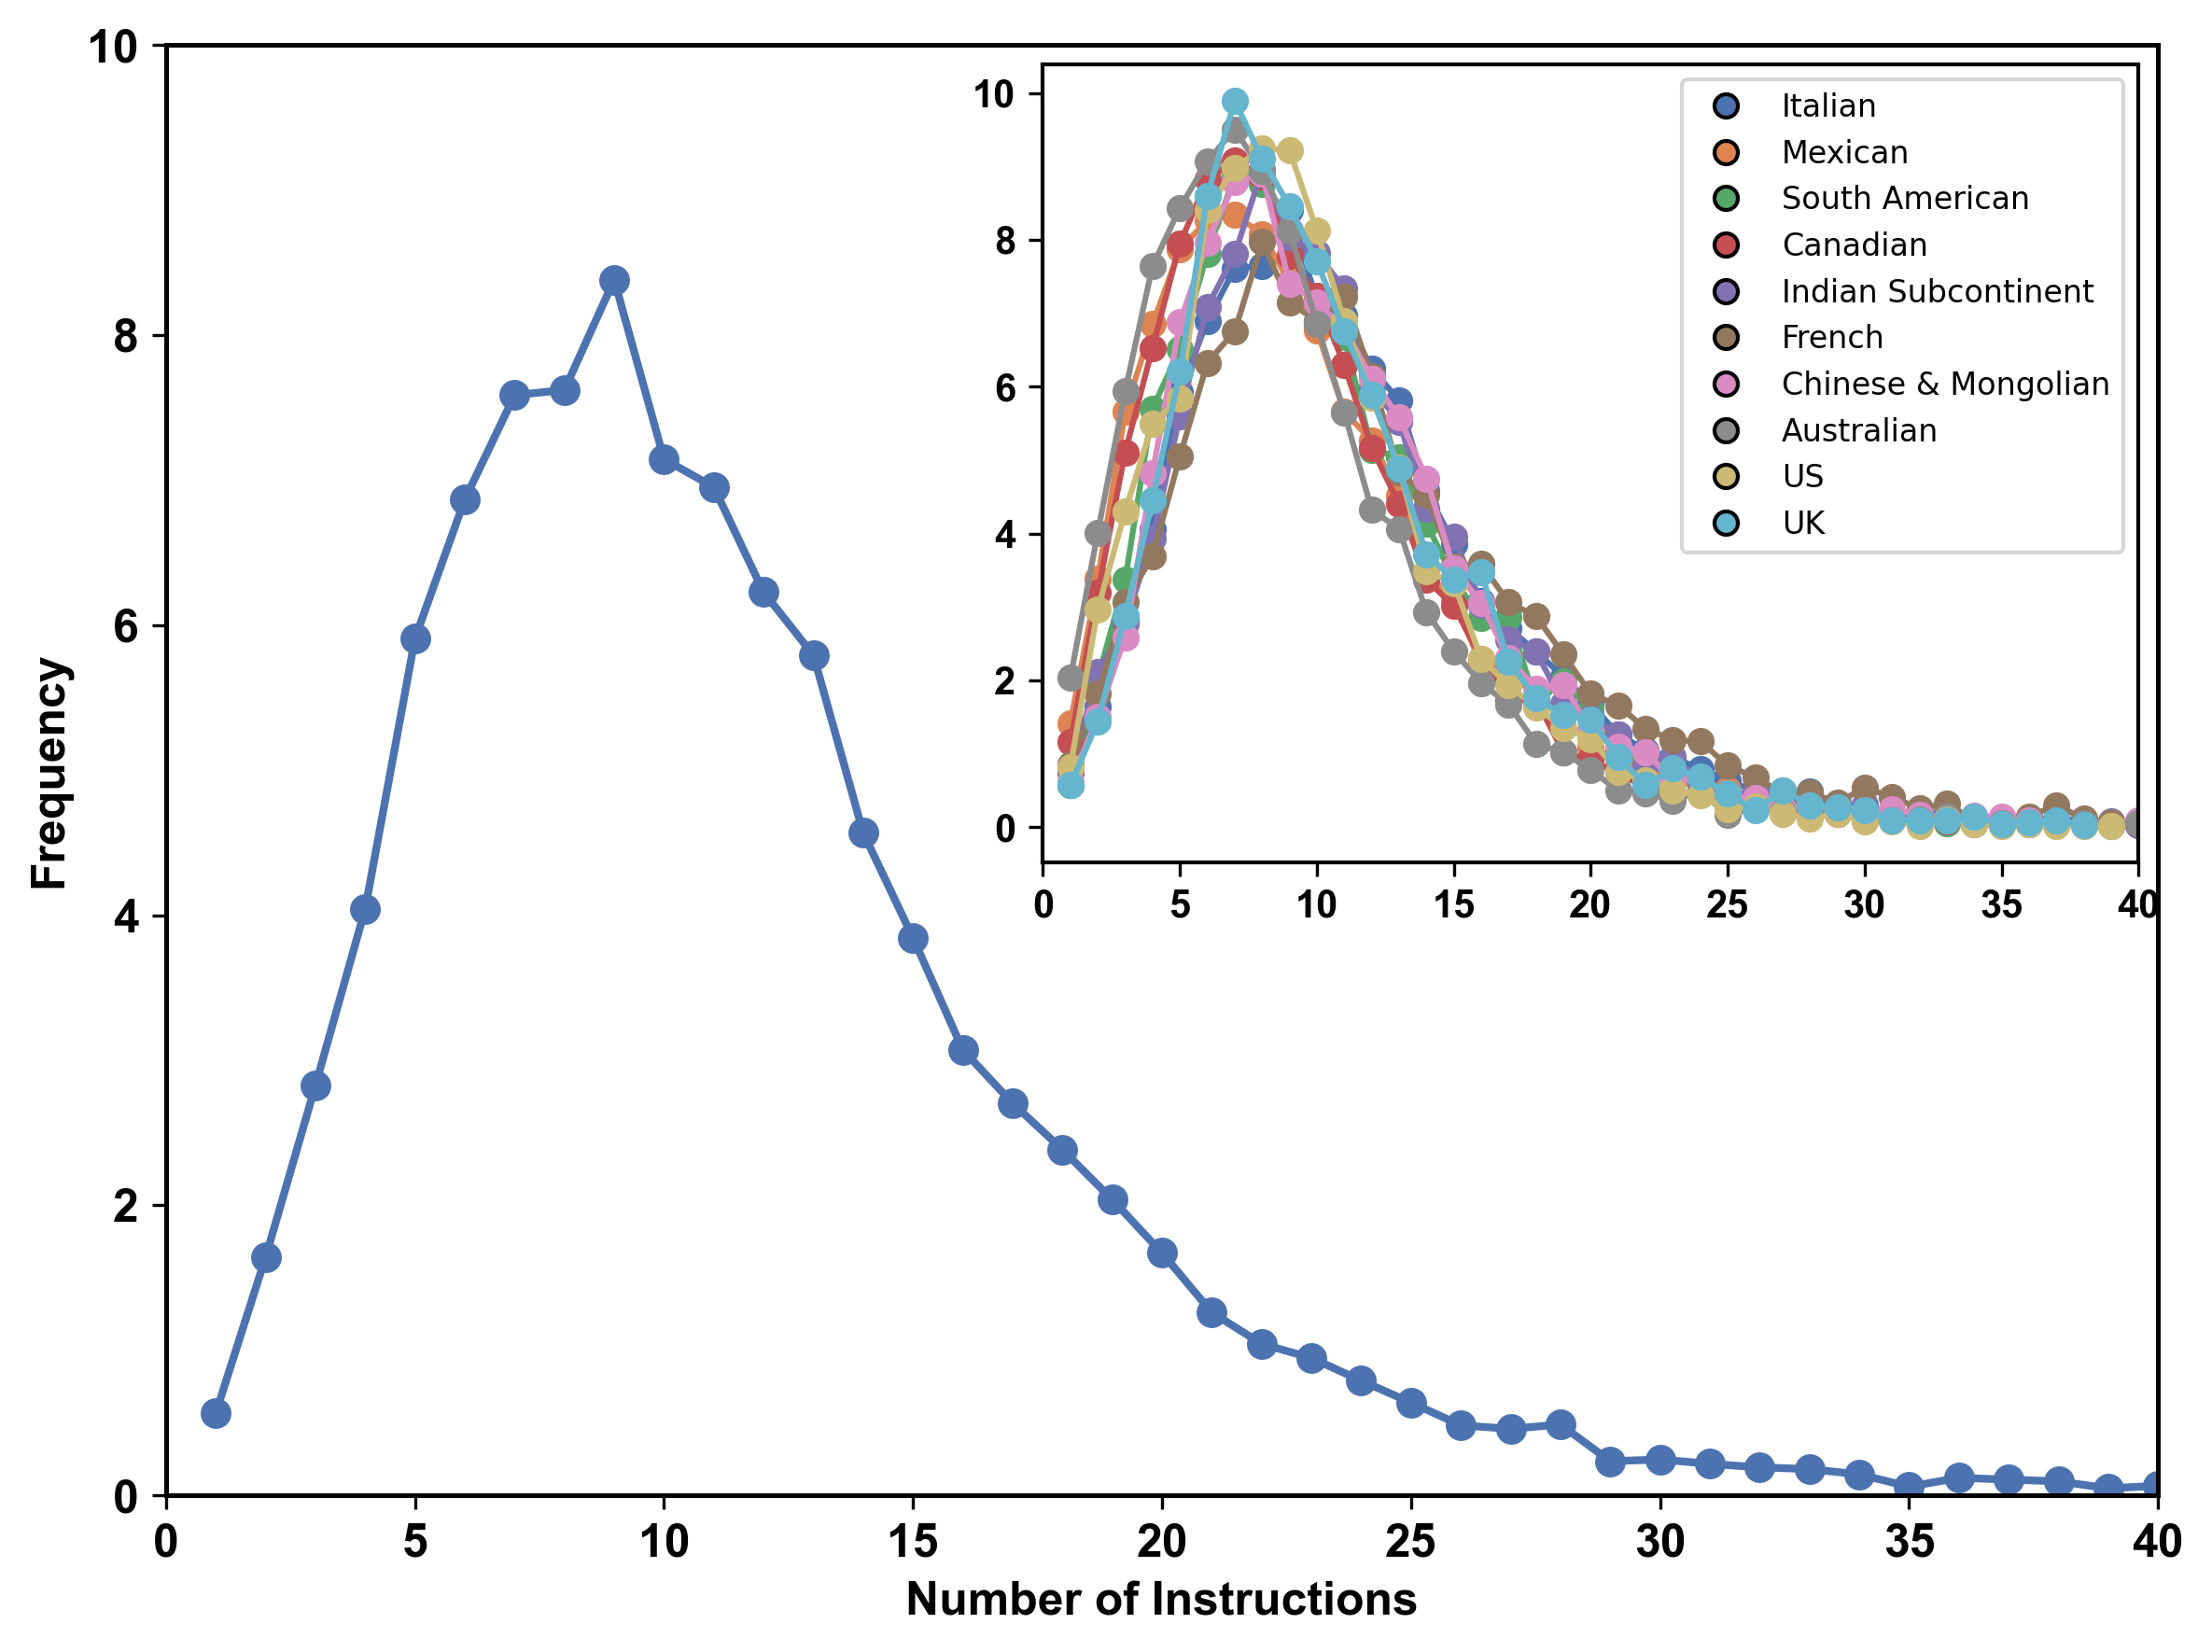

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

# =========================================================
# 📁 BASE PATHS
# =========================================================
base_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine"
instr_path = os.path.join(base_path, "Instructions")

# =========================================================
# ===== 1️⃣ MAIN GRAPH (ALL RECIPES)
# =========================================================
main_file = os.path.join(instr_path, "RecipeDB1_Italian_16574_instructions.csv")
df = pd.read_csv(main_file)

df.columns = df.columns.str.strip().str.lower()

df["recipe_size"] = df["steps"].apply(
    lambda x: len([s for s in re.split(r'[.;]', str(x)) if s.strip()])
)

recipe_sizes = df["recipe_size"].values

size_counts = pd.Series(recipe_sizes).value_counts().sort_index()
sizes = size_counts.index
percentages = (size_counts.values / size_counts.values.sum()) * 100

avg_size = round(np.mean(recipe_sizes))

# =========================================================
# ===== 2️⃣ MAIN PLOT
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.plot(
    sizes,
    percentages,
    marker='o',
    markersize=7,
    markeredgewidth=0.9,
    linewidth=2,
    color='#4C72B0'
)

ax.set_xlabel("Number of Instructions", fontname='Arial', fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontname='Arial', fontsize=12, fontweight='bold')

ax.set_xlim(0, 40)
ax.set_xticks(range(0, 41, 5))

max_y = int(max(percentages)) + 2
ax.set_yticks(range(0, max_y + 2, 2))
ax.set_ylim(0, max_y)

plt.xticks(fontname='Arial', fontsize=12, fontweight='bold')
plt.yticks(fontname='Arial', fontsize=12, fontweight='bold')

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

ax.grid(False)

# =========================================================
# ===== 3️⃣ INSET SUBGRAPH (TOP 10 CUISINES)
# =========================================================
ax_inset = inset_axes(ax, width="55%", height="55%", loc="upper right")

files = [
    ("Italian", "RecipeDB1_Italian_16574_instructions.csv"),
    ("Mexican", "RecipeDB1_Mexican_14447_instructions.csv"),
    ("South American", "RecipeDB1_South_American_7171_instructions.csv"),
    ("Canadian", "RecipeDB1_Canadian_6694_instructions.csv"),
    ("Indian Subcontinent", "RecipeDB1_Indian_Subcontinent_6463_instructions.csv"),
    ("French", "RecipeDB1_French_6375_instructions.csv"),
    ("Chinese & Mongolian", "RecipeDB1_Chinese_and_Mongolian_5888_instructions.csv"),
    ("Australian", "RecipeDB1_Australian_5819_instructions.csv"),
    ("US", "RecipeDB1_US_5025_instructions.csv"),
    ("UK", "RecipeDB1_UK_4396_instructions.csv")
]

colors = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"
]

legend_elements = []

for i, (cuisine, file) in enumerate(files):
    path = os.path.join(instr_path, file)
    
    df_sub = pd.read_csv(path)
    df_sub.columns = df_sub.columns.str.strip().str.lower()

    df_sub["recipe_size"] = df_sub["steps"].apply(
        lambda x: len([s for s in re.split(r'[.;]', str(x)) if s.strip()])
    )

    df_sub = df_sub[df_sub["recipe_size"] <= 40]

    size_counts = pd.Series(df_sub["recipe_size"]).value_counts().sort_index()
    sizes_sub = size_counts.index
    percentages_sub = (size_counts.values / size_counts.values.sum()) * 100

    ax_inset.plot(
        sizes_sub,
        percentages_sub,
        marker='o',
        markersize=6,
        linewidth=1.5,
        color=colors[i]
    )

    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=colors[i],
            markeredgecolor='black',
            markersize=6,
            label=cuisine
        )
    )

ax_inset.set_xlim(0, 40)
ax_inset.set_xticks(range(0, 41, 5))

ax_inset.tick_params(labelsize=10)
for label in ax_inset.get_xticklabels() + ax_inset.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontweight('bold')

for spine in ax_inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

ax_inset.grid(False)

ax_inset.legend(handles=legend_elements, loc='upper right', fontsize=8, frameon=True)

# =========================================================
# ===== 4️⃣ SAVE (IN YOUR CODE FOLDER)
# =========================================================
output_file = os.path.join(
    base_path,
    "Recipe_Instruction_Size_Across_Global_Cuisines.png"
)

plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()


C:\Users\madhu\AppData\Local\Temp\ipykernel_30012\4006849658.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


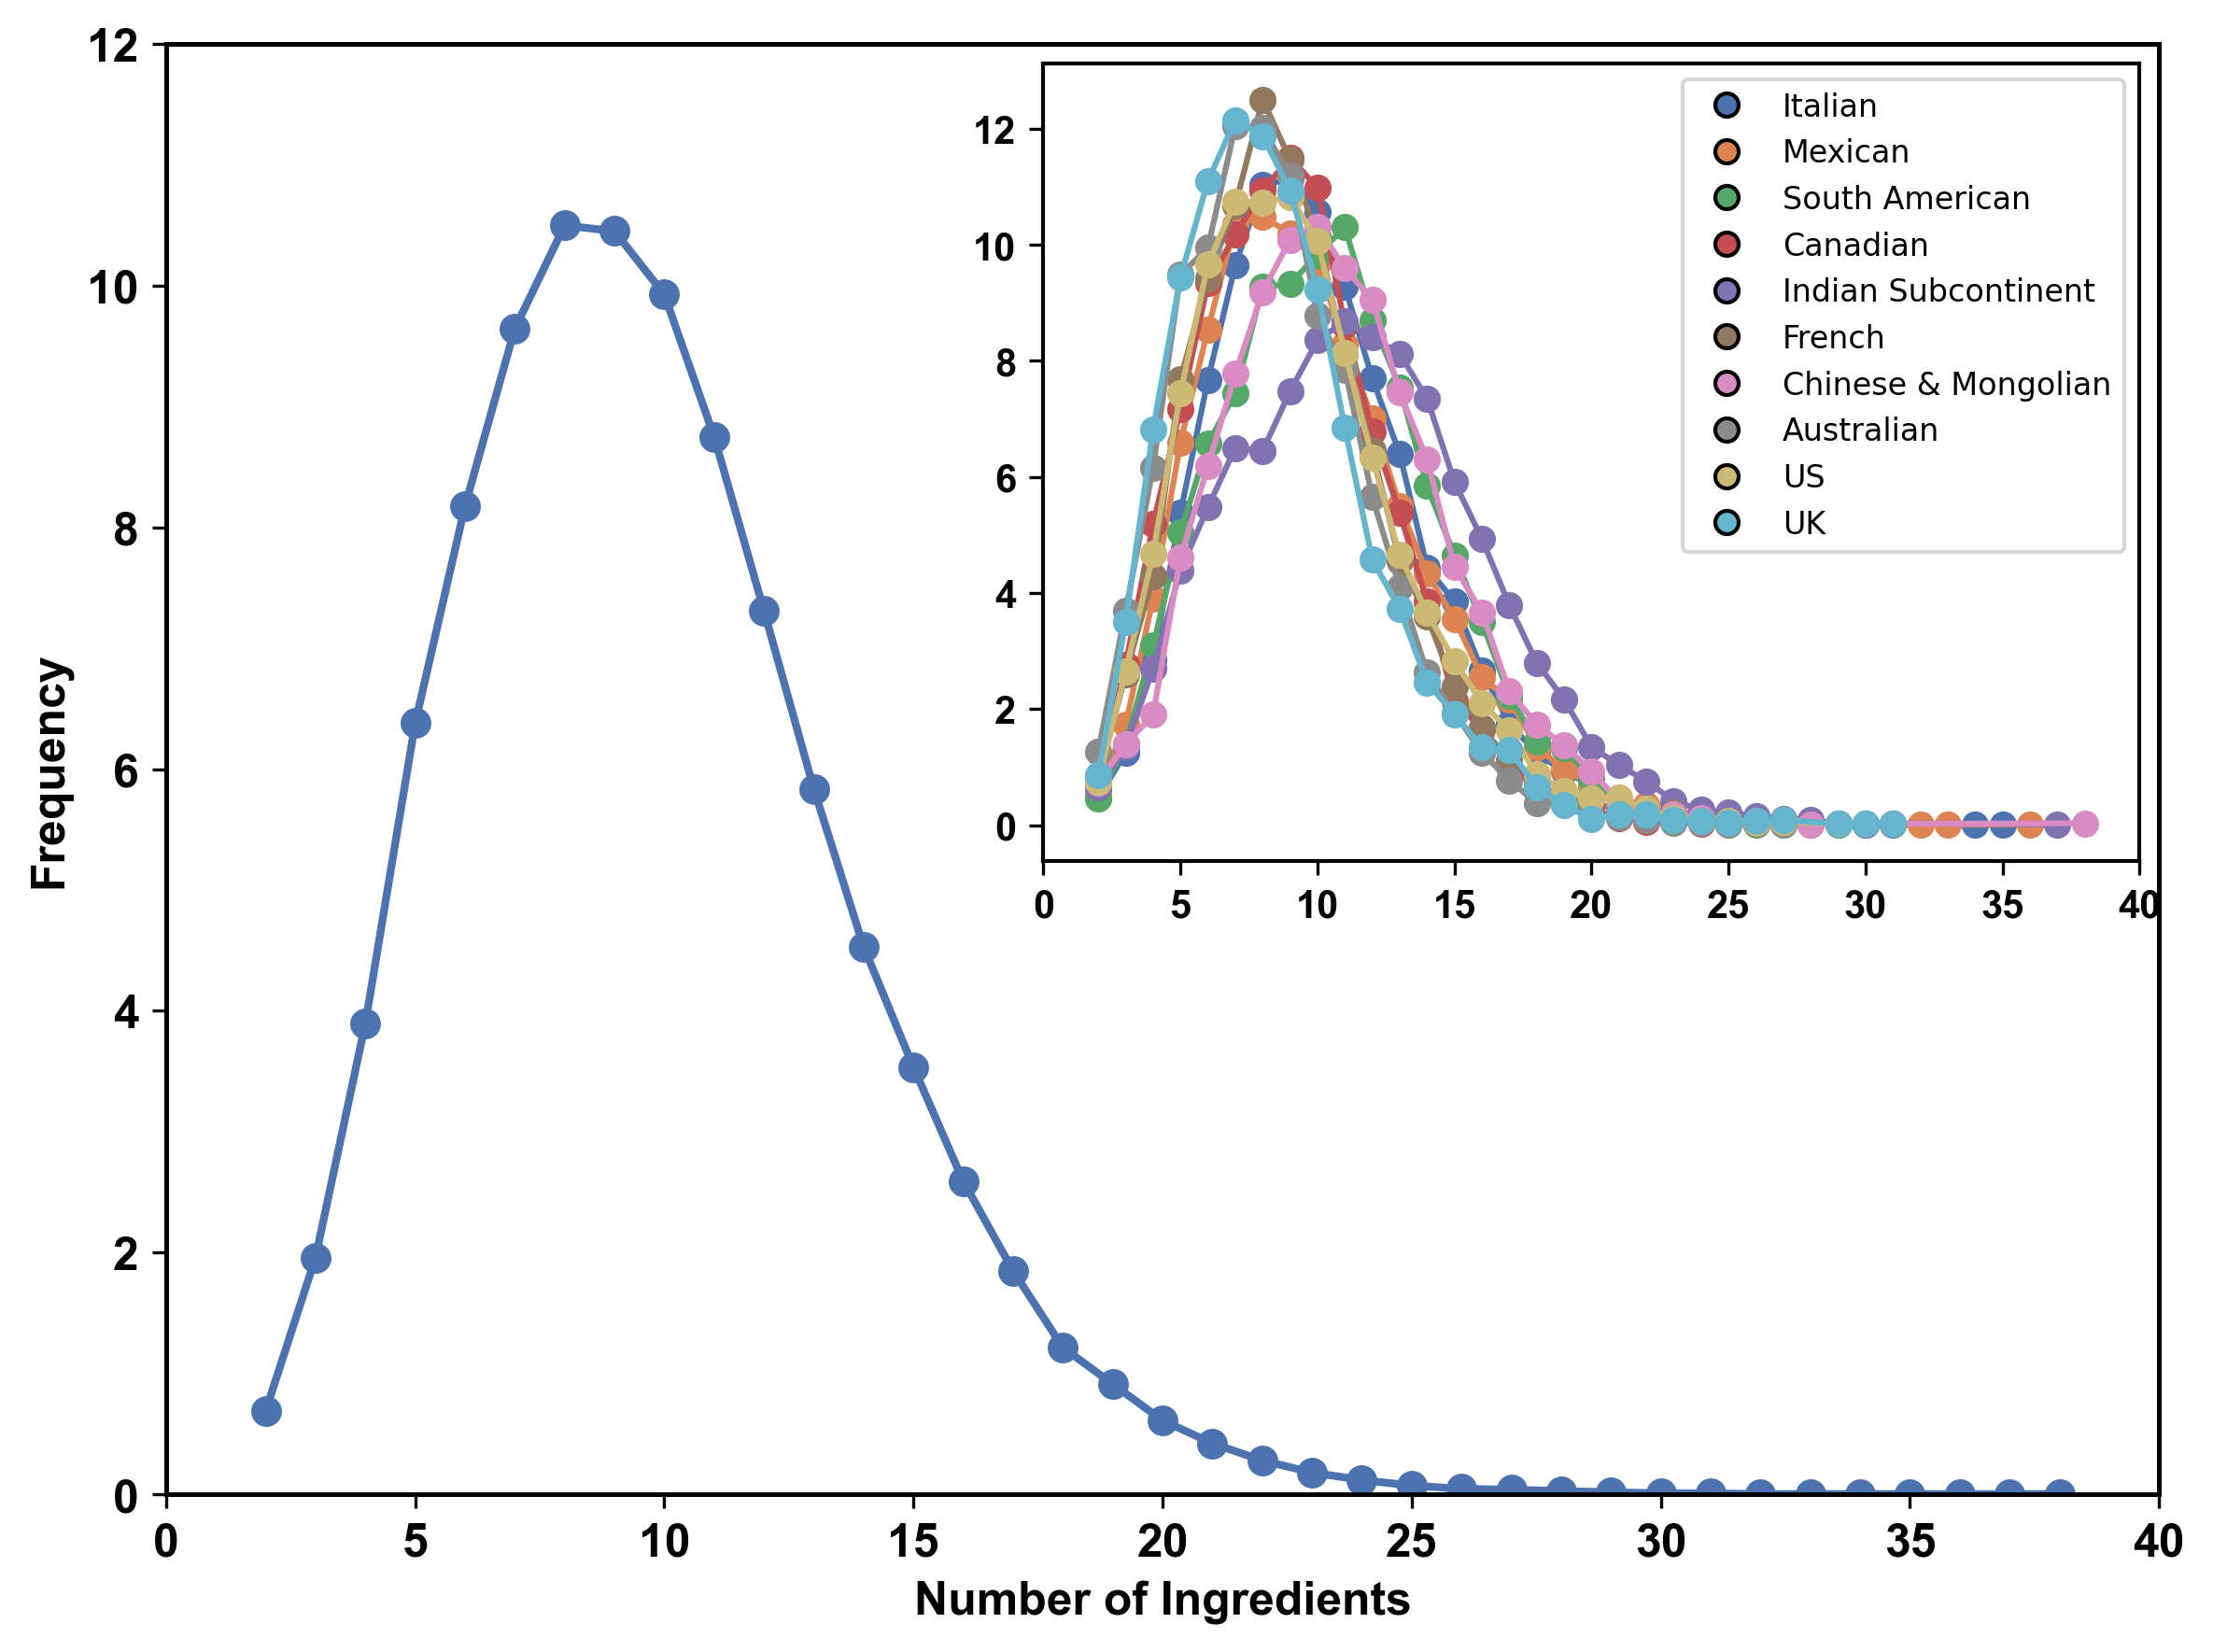

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

# =========================================================
# 📁 BASE PATHS
# =========================================================
base_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine"
ing_path = os.path.join(base_path, "Ingredients")

# =========================================================
# ===== 1️⃣ MAIN GRAPH (ALL RECIPES)
# =========================================================
main_file = os.path.join(ing_path, "Recipe_Ingredient_Phrases.csv")

df = pd.read_csv(main_file)
df.columns = df.columns.str.strip()

# compute recipe size using "|" separator
df["recipe_size"] = df["Ingredient_Phrases"].fillna("").apply(
    lambda x: len([i for i in str(x).split("|") if i.strip()])
)

recipe_sizes = df["recipe_size"].values

size_counts = pd.Series(recipe_sizes).value_counts().sort_index()
sizes = size_counts.index
percentages = (size_counts.values / size_counts.values.sum()) * 100

avg_size = round(np.mean(recipe_sizes))

# =========================================================
# ===== 2️⃣ MAIN PLOT
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.plot(
    sizes,
    percentages,
    marker='o',
    markersize=7,
    markeredgewidth=0.9,
    linewidth=2,
    color='#4C72B0'
)

ax.set_xlabel("Number of Ingredients", fontname='Arial', fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontname='Arial', fontsize=12, fontweight='bold')

ax.set_xlim(0, 40)
ax.set_xticks(range(0, 41, 5))

max_y = int(max(percentages)) + 2
ax.set_yticks(range(0, max_y + 2, 2))
ax.set_ylim(0, max_y)

plt.xticks(fontname='Arial', fontsize=12, fontweight='bold')
plt.yticks(fontname='Arial', fontsize=12, fontweight='bold')

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

ax.grid(False)

# =========================================================
# ===== 3️⃣ INSET SUBGRAPH (TOP 10 CUISINES)
# =========================================================
ax_inset = inset_axes(ax, width="55%", height="55%", loc="upper right")

files = [
    ("Italian", "1. RecipeDB1_Ingredient_Phrases_Italian_16574_grouped.csv"),
    ("Mexican", "2. RecipeDB1_Ingredient_Phrases_Mexican_14447_grouped.csv"),
    ("South American", "3. RecipeDB1_Ingredient_Phrases_South_American_grouped.csv"),
    ("Canadian", "4. RecipeDB1_Ingredient_Phrases_Canadian_6694_grouped.csv"),
    ("Indian Subcontinent", "5. RecipeDB1_Ingredient_Phrases_Indian_Subcontinent_grouped.csv"),
    ("French", "6. RecipeDB1_Ingredient_Phrases_French_6375_grouped.csv"),
    ("Chinese & Mongolian", "7. RecipeDB1_Ingredient_Phrases_Chinese_and_grouped.csv"),
    ("Australian", "8. RecipeDB1_Ingredient_Phrases_Australian_5819_grouped.csv"),
    ("US", "9. RecipeDB1_Ingredient_Phrases_US_5025_grouped.csv"),
    ("UK", "10. RecipeDB1_Ingredient_Phrases_UK_4396_grouped.csv")
]

colors = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"
]

legend_elements = []

for i, (cuisine, file) in enumerate(files):

    file_path = os.path.join(ing_path, file)
    df_sub = pd.read_csv(file_path)
    df_sub.columns = df_sub.columns.str.strip()

    # compute recipe size
    df_sub["recipe_size"] = df_sub["Ingredient_Phrases"].fillna("").apply(
        lambda x: len([i for i in str(x).split("|") if i.strip()])
    )

    df_sub = df_sub[df_sub["recipe_size"] <= 40]

    size_counts = pd.Series(df_sub["recipe_size"]).value_counts().sort_index()
    sizes_sub = size_counts.index
    percentages_sub = (size_counts.values / size_counts.values.sum()) * 100

    ax_inset.plot(
        sizes_sub,
        percentages_sub,
        marker='o',
        markersize=6,
        linewidth=1.5,
        color=colors[i]
    )

    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=colors[i],
            markeredgecolor='black',
            markersize=6,
            label=cuisine
        )
    )

# =========================================================
# ===== INSET STYLE
# =========================================================
ax_inset.set_xlim(0, 40)
ax_inset.set_xticks(range(0, 41, 5))

ax_inset.tick_params(labelsize=10)
for label in ax_inset.get_xticklabels() + ax_inset.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontweight('bold')

for spine in ax_inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

ax_inset.grid(False)

ax_inset.legend(handles=legend_elements, loc='upper right', fontsize=8, frameon=True)

# =========================================================
# ===== 4️⃣ SAVE FIGURE
# =========================================================
output_file = os.path.join(
    base_path,
    "Recipe_Ingredient_Size_Across_Global_Cuisines.png"
)

plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()


In [34]:
import pandas as pd
import os

# =========================================================
# 📁 BASE PATH
# =========================================================
base_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine"

general_file = os.path.join(base_path, "RecipeDB_general.csv")
ingredient_file = os.path.join(base_path, "Recipe_Ingredient_Phrases.csv")

# =========================================================
# 📊 LOAD DATA
# =========================================================
df_general = pd.read_csv(general_file)
df_ing = pd.read_csv(ingredient_file)

df_general.columns = df_general.columns.str.strip()
df_ing.columns = df_ing.columns.str.strip()

# =========================================================
# 🔥 FIX: CREATE Recipe_id FROM ROW INDEX
# =========================================================
df_ing["Recipe_id"] = df_ing.index + 1   # assuming Recipe_id starts from 1

# =========================================================
# 🔗 MERGE
# =========================================================
merged = pd.merge(
    df_general[["Recipe_id", "Region"]],
    df_ing[["Recipe_id", "Ingredient_Phrases"]],
    on="Recipe_id",
    how="inner"
)

# =========================================================
# 💾 SAVE OUTPUT
# =========================================================
output_file = os.path.join(base_path, "Recipe_Region_Ingredients.csv")
merged.to_csv(output_file, index=False)

print("✅ Saved:", output_file)
print("📊 Total rows:", len(merged))

C:\Users\madhu\AppData\Local\Temp\ipykernel_30012\1057633122.py:15: DtypeWarning: Columns (2,3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_general = pd.read_csv(general_file)


✅ Saved: C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine\Recipe_Region_Ingredients.csv
📊 Total rows: 86993


In [40]:
import pandas as pd
import os

# =========================================================
# 📁 PATH
# =========================================================
base_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine"

general_file = os.path.join(base_path, "RecipeDB_general.csv")
ingredient_file = os.path.join(base_path, "Recipe_Ingredient_Phrases.csv")

# =========================================================
# 📊 LOAD DATA
# =========================================================
df_general = pd.read_csv(general_file)
df_ing = pd.read_csv(ingredient_file)

df_general.columns = df_general.columns.str.strip()
df_ing.columns = df_ing.columns.str.strip()

# =========================================================
# ⚠️ CRITICAL FIX:
# Ensure BOTH Recipe_id columns exist correctly
# =========================================================

# If ingredient file does NOT have Recipe_id, we assume correct alignment
if "Recipe_id" not in df_ing.columns:
    df_ing = df_ing.copy()
    df_ing["Recipe_id"] = df_general["Recipe_id"]  # SAFE ALIGNMENT

# =========================================================
# 🔗 USE LEFT JOIN (KEEP ALL GENERAL RECIPES)
# =========================================================
merged = pd.merge(
    df_general[["Recipe_id", "Region"]],
    df_ing[["Recipe_id", "Ingredient_Phrases"]],
    on="Recipe_id",
    how="left"   # 🔥 IMPORTANT CHANGE
)

# =========================================================
# 💾 SAVE
# =========================================================
output_file = os.path.join(base_path, "Recipe_Region_Ingredients.csv")
merged.to_csv(output_file, index=False)

print("✅ Saved:", output_file)
print("📊 Total rows:", len(merged))
print("📊 Missing ingredient rows:", merged["Ingredient_Phrases"].isna().sum())

C:\Users\madhu\AppData\Local\Temp\ipykernel_30012\3022597561.py:15: DtypeWarning: Columns (2,3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_general = pd.read_csv(general_file)


✅ Saved: C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine\Recipe_Region_Ingredients.csv
📊 Total rows: 118083
📊 Missing ingredient rows: 0


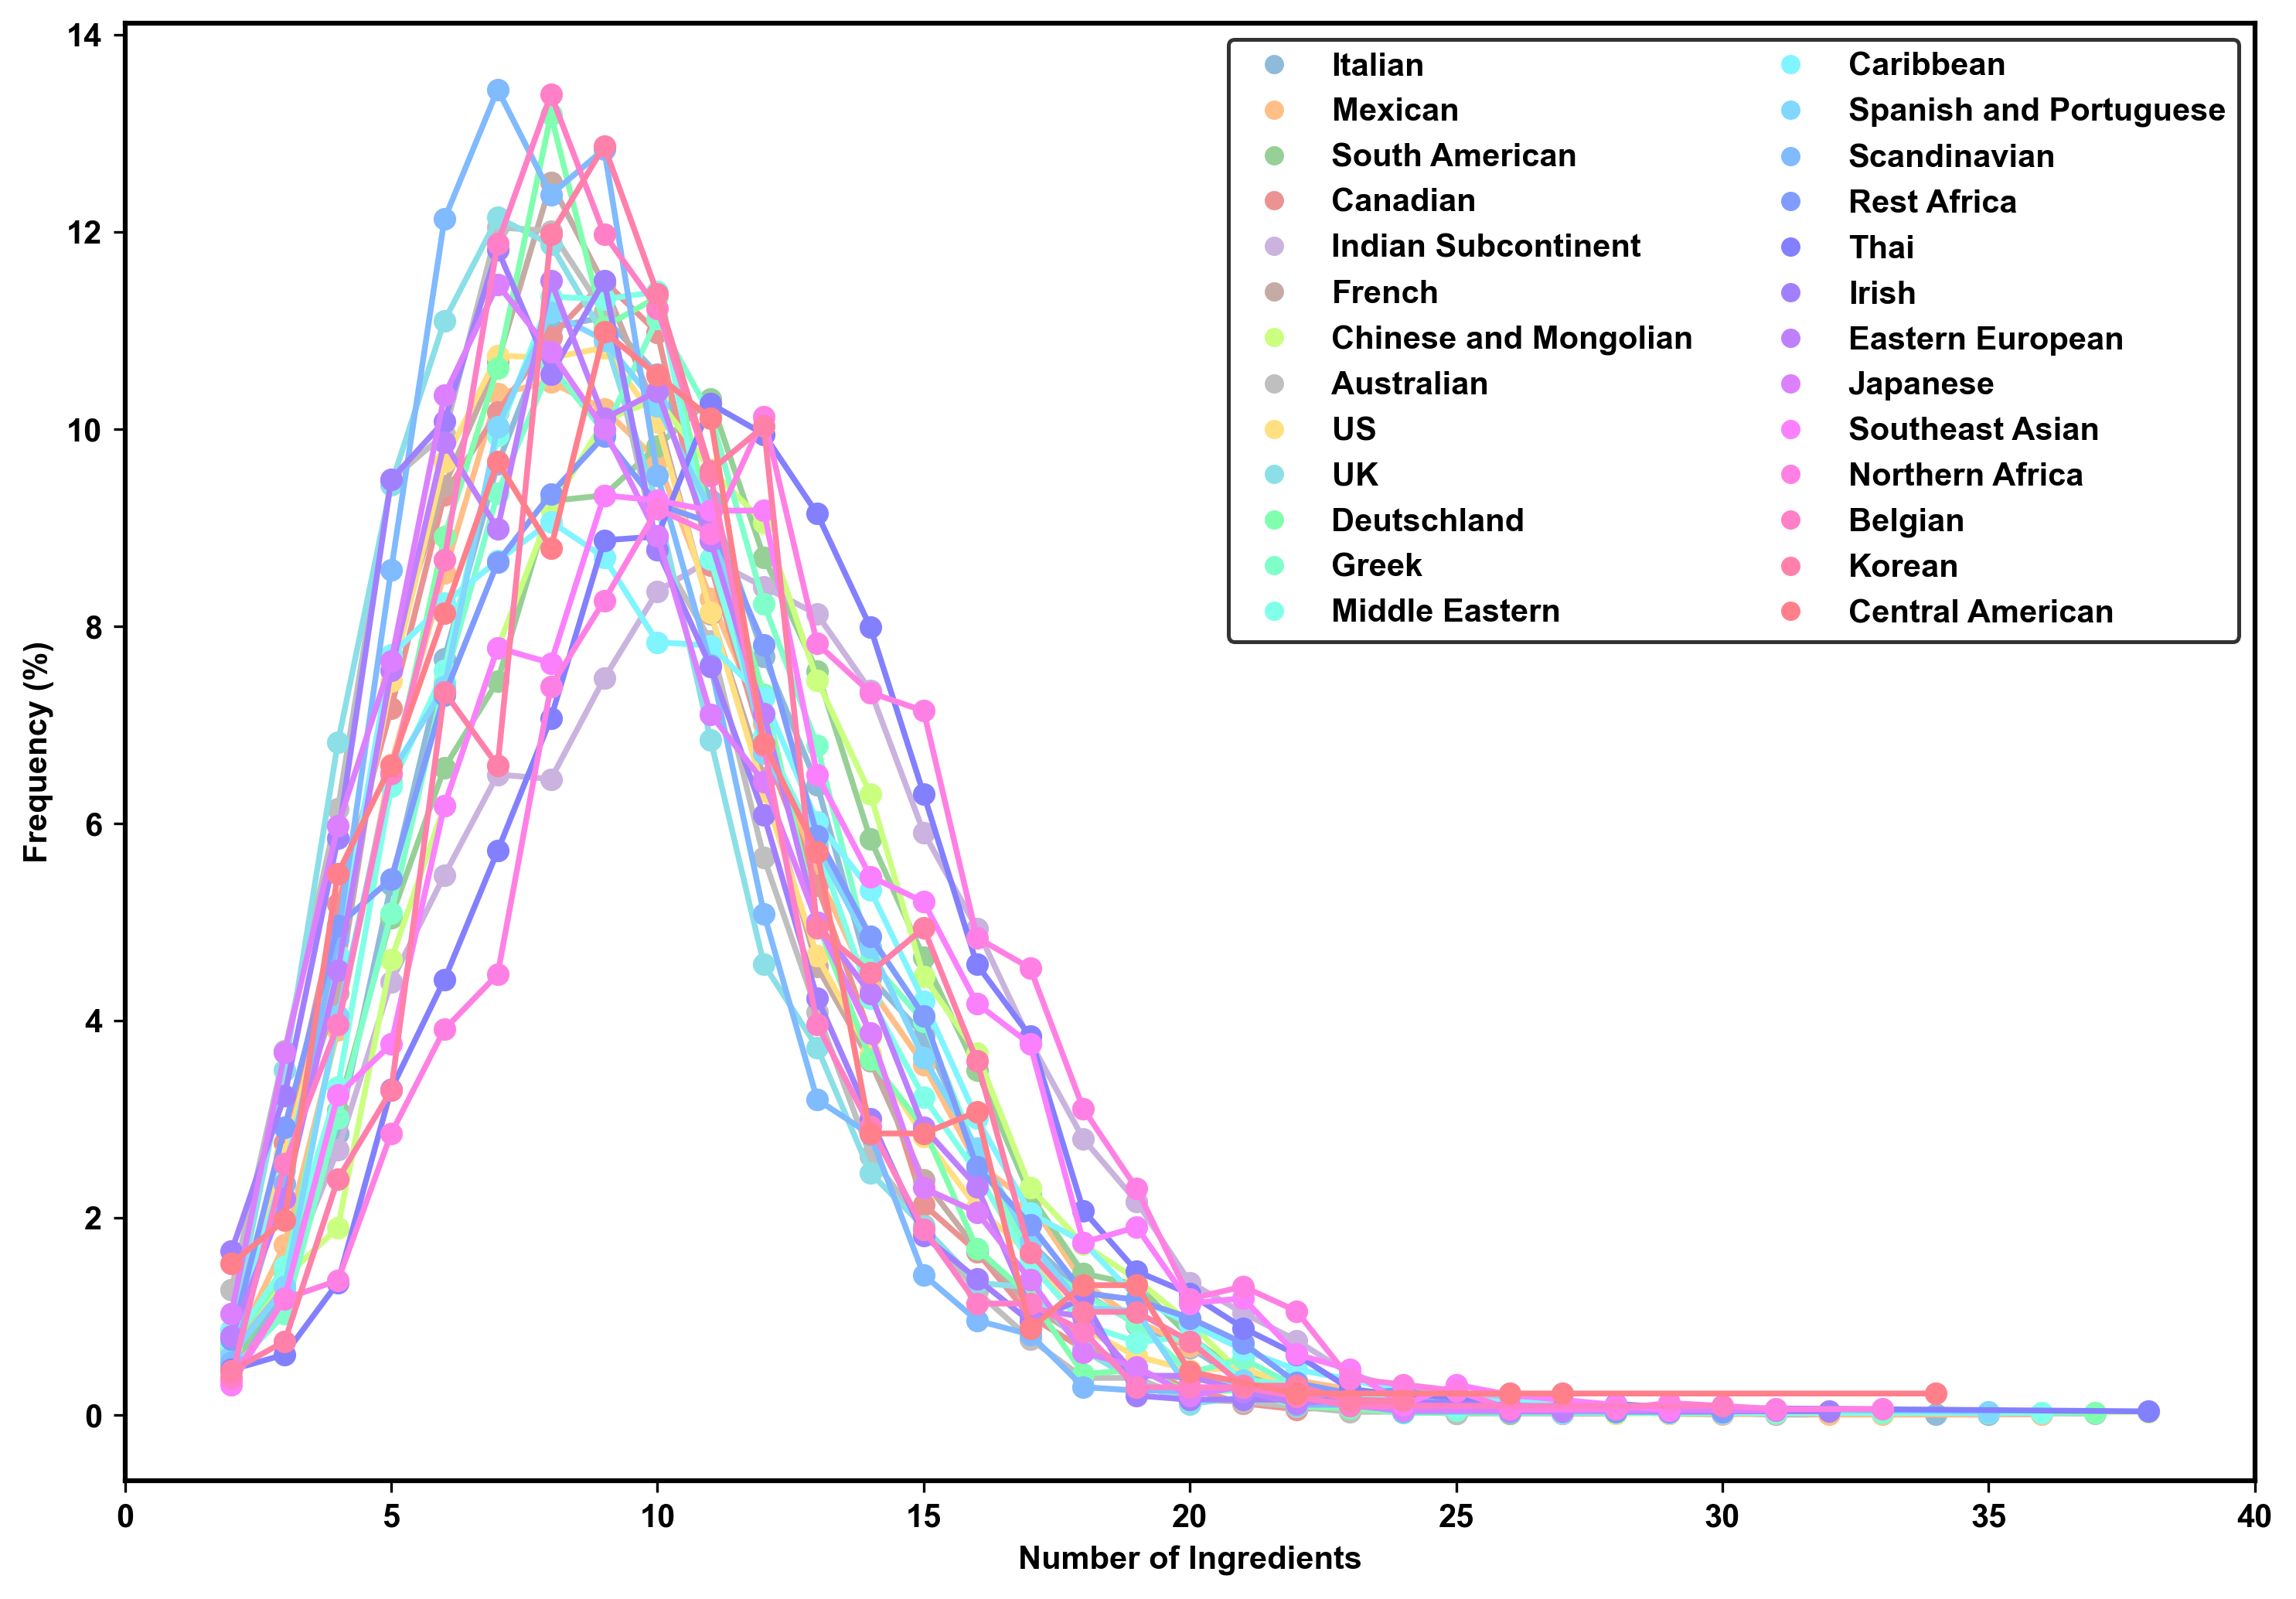

✅ Saved: C:\Users\madhu\Desktop\RecipeDB1_Updated_Code_Git\Cuisine\Region_Ingredient_Size_Distribution.png


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# =========================================================
# 🎨 Function to lighten color
# =========================================================
def lighten_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = mcolors.to_rgb(c)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================================================
# 📁 INPUT FILE
# =========================================================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cuisine/Region_Ingredient_Phrases.csv"

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# =========================================================
# 🍽️ COMPUTE INGREDIENT COUNT PER RECIPE
# =========================================================
df["recipe_size"] = df["Ingredient_Phrases"].fillna("").apply(
    lambda x: len([i for i in str(x).split("|") if i.strip()])
)

# =========================================================
# 🌍 REGION ORDER
# =========================================================
regions = df["Region"].value_counts().index.tolist()

# =========================================================
# 🎨 COLORS
# =========================================================
base_colors = plt.cm.hsv(np.linspace(0, 1, len(regions)))
colors = [lighten_color(c, 0.5) for c in base_colors]

# Optional consistent palette for top cuisines
top10_colors = {
    "Italian": "#1f77b4",
    "Mexican": "#ff7f0e",
    "South American": "#2ca02c",
    "Canadian": "#d62728",
    "Indian Subcontinent": "#9467bd",
    "French": "#8c564b",
    "Chinese & Mongolian": "#e377c2",
    "Australian": "#7f7f7f",
    "US": "#ffbf00",
    "UK": "#17becf"
}

light_top10_colors = {k: lighten_color(v, 0.5) for k, v in top10_colors.items()}

# =========================================================
# 📊 PLOT
# =========================================================
plt.figure(figsize=(10, 7), dpi=300)
ax = plt.gca()

legend_elements = []

for i, region in enumerate(regions):

    region_df = df[df["Region"] == region]

    recipe_sizes = region_df["recipe_size"].values

    if len(recipe_sizes) == 0:
        continue

    size_counts = pd.Series(recipe_sizes).value_counts().sort_index()
    sizes = size_counts.index
    percentages = (size_counts.values / size_counts.values.sum()) * 100

    # 🎨 color selection
    color = light_top10_colors.get(region, colors[i])

    plt.plot(
        sizes,
        percentages,
        marker='o',
        linewidth=1.8,
        markersize=6,
        color=color
    )

    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=region,
            markerfacecolor=color,
            markersize=7
        )
    )

# =========================================================
# 🏷 LABELS
# =========================================================
plt.xlabel("Number of Ingredients", fontname='Arial', fontsize=10, fontweight='bold')
plt.ylabel("Frequency (%)", fontname='Arial', fontsize=10, fontweight='bold')

# =========================================================
# 📏 AXES
# =========================================================
ax.set_xlim(0, 40)
ax.set_xticks(range(0, 41, 5))

# =========================================================
# 🔤 TICKS
# =========================================================
plt.xticks(fontname='Arial', fontsize=10, fontweight='bold')
plt.yticks(fontname='Arial', fontsize=10, fontweight='bold')

# =========================================================
# 🧱 BORDER
# =========================================================
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# =========================================================
# 📌 LEGEND
# =========================================================
legend = plt.legend(
    handles=legend_elements,
    fontsize=9,
    loc='upper right',
    ncol=2,
    frameon=True,
    prop={'family': 'Arial', 'weight': 'bold'}
)

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1.2)

plt.grid(False)

# =========================================================
# 💾 SAVE
# =========================================================
output_path = os.path.join(os.getcwd(), "Region_Ingredient_Size_Distribution.png")

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved:", output_path)